<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Experiment%203/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Multiple Linear Regression
Intercept: 0.0034464322524057067
Coefficients: [0.24985511 0.25043523 0.24955168 0.24986871]

y=0.0034 + 0.2499*SEM 1 + 0.2504*SEM 2 + 0.2496*SEM 3 + 0.2499*SEM 4

Mean Squared Error: 7.405117632058216e-06
Mean Absolute Error: 0.0024001414766533897
Root Mean square Error:  0.0027212345786532654
R-squared: 0.9999992394772776
Enter the data for prediction :- 
Enter the 1st Semester marks: 9
Enter the 2nd Semester marks: 8
Enter the 3rd Semester marks: 9
Enter the 4th Semester marks: 8
The predicted 5th sem mark is :  8.500539046352888


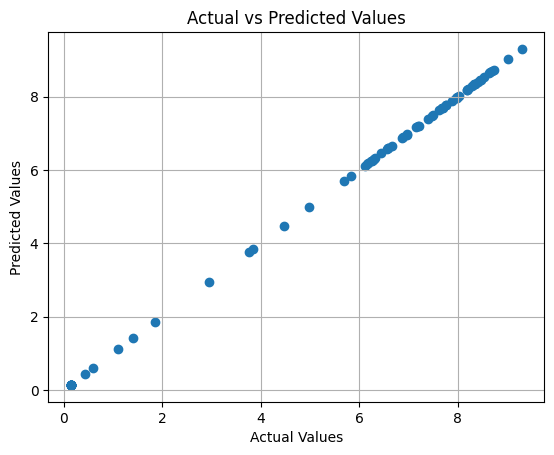

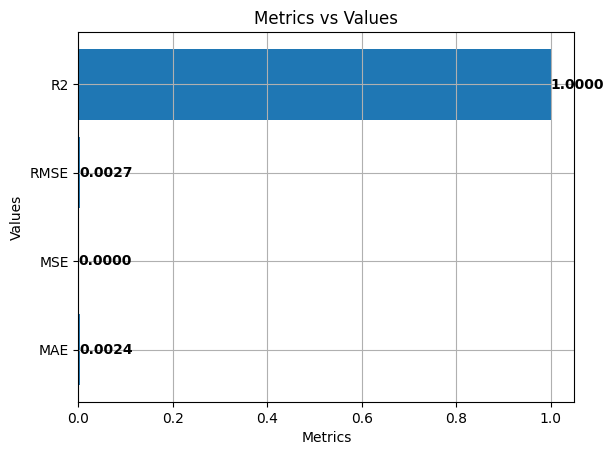

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('studentGradeDataSet.csv')

x = data.drop('SEM 5', axis=1)
y = data['SEM 5']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)

pred_model = model.predict(x_test)

mse = mean_squared_error(y_test, pred_model)
mae = mean_absolute_error(y_test, pred_model)
rmse  = np.sqrt(mse)
r2 = r2_score(y_test, pred_model)

intercept = model.intercept_
coefficients = model.coef_
eqn = f"y={intercept:.4f} + " + " + ".join([f"{coef:.4f}*{col}" for coef, col in zip(coefficients, x.columns)])

print("--- Multiple Linear Regression")
print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("\n"+eqn)
print("\nMean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean square Error: ", rmse)
print("R-squared:", r2)

print("Enter the data for prediction :- ")
s1 = int(input("Enter the 1st Semester marks: "))
s2 = int(input("Enter the 2nd Semester marks: "))
s3 = int(input("Enter the 3rd Semester marks: "))
s4 = int(input("Enter the 4th Semester marks: "))
test = pd.DataFrame({"SEM 1" : [s1],
                     "SEM 2" : [s2],
                     "SEM 3" : [s3],
                     "SEM 4" : [s4]})

pred_val = model.predict(test)
print("The predicted 5th sem mark is : ", pred_val[0])

plt.scatter(y_test, pred_model)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

metrics = ["MAE", "MSE", "RMSE", "R2"]
values = [mae, mse, rmse, r2]

bars = plt.barh(metrics, values)
for bar in bars:
  width = bar.get_width()
  plt.annotate(f"{width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2),ha="left", va="center", fontweight="bold")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.title("Metrics vs Values")
plt.grid(True)
plt.show()



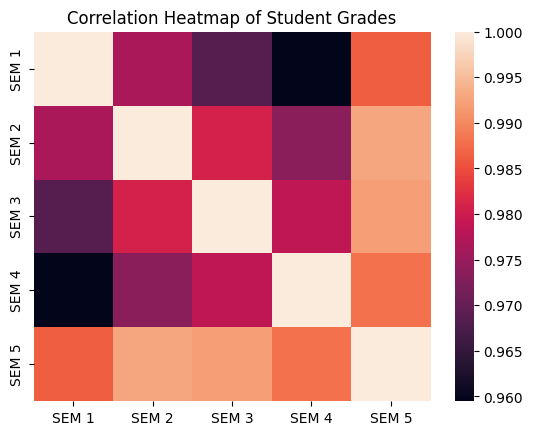

In [26]:
#heat map
sns.heatmap(data.corr())
plt.title('Correlation Heatmap of Student Grades')
plt.show()

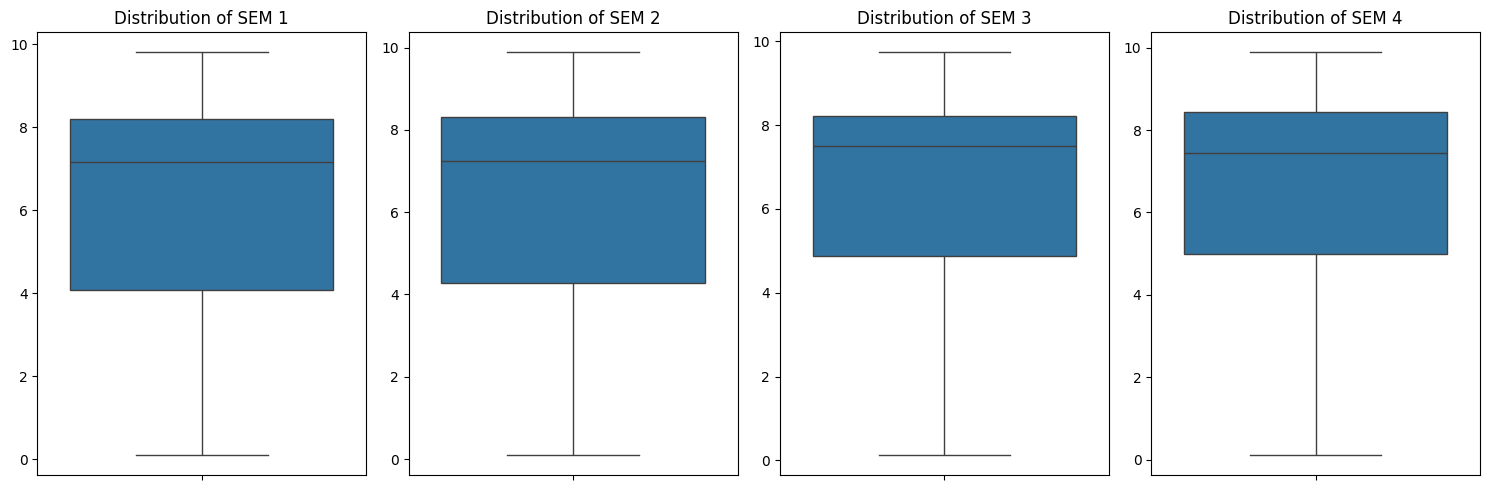

In [27]:
fig, axes = plt.subplots(1, len(x.columns), figsize=(15, 5))
for i, col in enumerate(x.columns):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()


--- Simple Linear Regression for SEM 1 ---
Equation: y = 0.3370 + 0.9661*SEM 1
Mean Squared Error: 0.1802
Mean Absolute Error: 0.3519
Root Mean Squared Error: 0.4245
R-squared: 0.9827


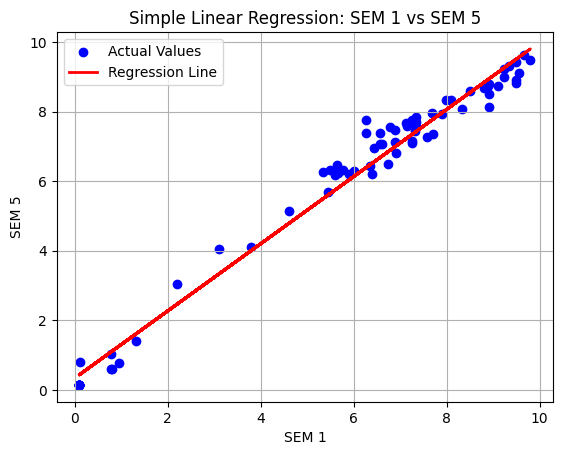


--- Simple Linear Regression for SEM 2 ---
Equation: y = 0.1694 + 0.9786*SEM 2
Mean Squared Error: 0.1175
Mean Absolute Error: 0.2454
Root Mean Squared Error: 0.3428
R-squared: 0.9887


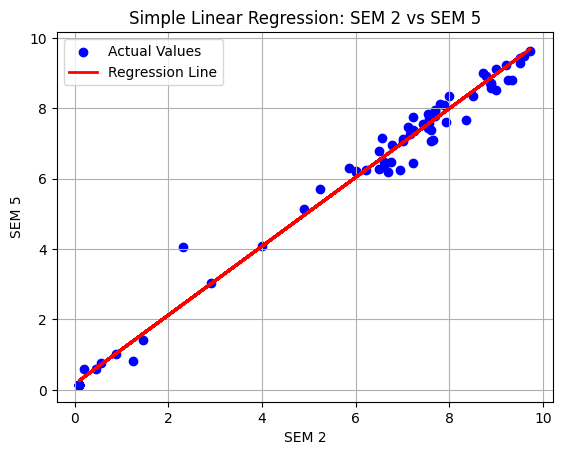


--- Simple Linear Regression for SEM 3 ---
Equation: y = 0.0032 + 0.9901*SEM 3
Mean Squared Error: 0.1285
Mean Absolute Error: 0.2618
Root Mean Squared Error: 0.3585
R-squared: 0.9876


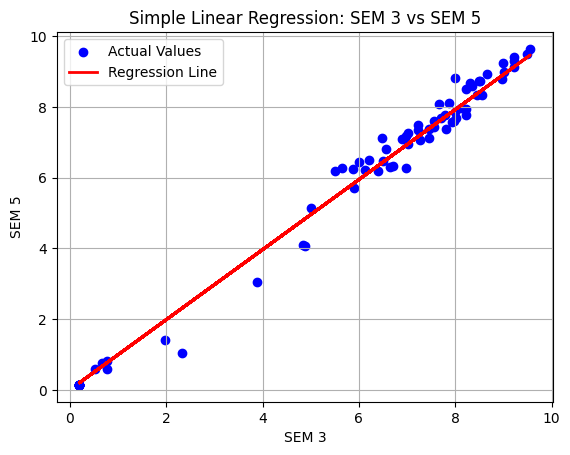


--- Simple Linear Regression for SEM 4 ---
Equation: y = 0.0326 + 0.9774*SEM 4
Mean Squared Error: 0.2284
Mean Absolute Error: 0.3557
Root Mean Squared Error: 0.4779
R-squared: 0.9780


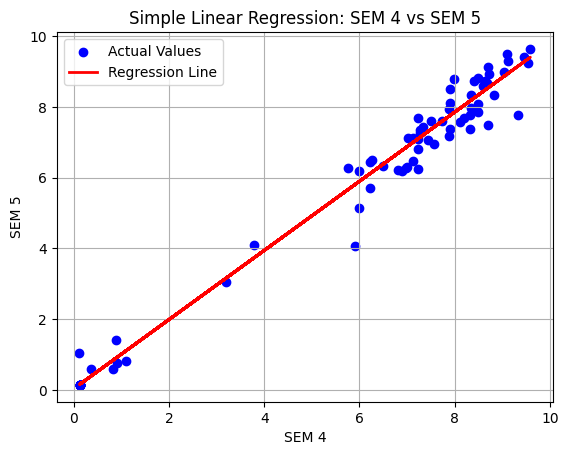

In [28]:
for feature in x.columns:
    print(f"\n--- Simple Linear Regression for {feature} ---")
    X_simple = data[[feature]]
    y_simple = data['SEM 5']

    X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

    model_simple = LinearRegression()
    model_simple.fit(X_train_simple, y_train_simple)

    predictions_simple = model_simple.predict(X_test_simple)

    mse_simple = mean_squared_error(y_test_simple, predictions_simple)
    mae_simple = mean_absolute_error(y_test_simple, predictions_simple)
    rmse_simple = np.sqrt(mse_simple)
    r2_simple = r2_score(y_test_simple, predictions_simple)

    intercept_simple = model_simple.intercept_
    coefficient_simple = model_simple.coef_[0]

    print(f"Equation: y = {intercept_simple:.4f} + {coefficient_simple:.4f}*{feature}")
    print(f"Mean Squared Error: {mse_simple:.4f}")
    print(f"Mean Absolute Error: {mae_simple:.4f}")
    print(f"Root Mean Squared Error: {rmse_simple:.4f}")
    print(f"R-squared: {r2_simple:.4f}")

    plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Values')
    plt.plot(X_test_simple, predictions_simple, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(feature)
    plt.ylabel('SEM 5')
    plt.title(f'Simple Linear Regression: {feature} vs SEM 5')
    plt.legend()
    plt.grid(True)
    plt.show()